In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, ToggleButtons
from google.colab import files
from PIL import Image, ImageOps

Saving nb_angled.jpg to nb_angled.jpg
(2048, 1536, 3)


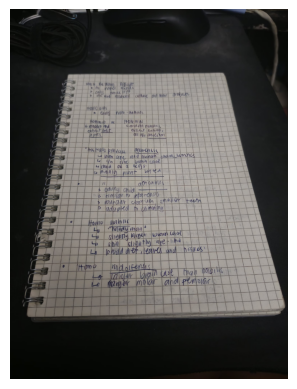

In [2]:
#Document Scanner Pipeline


doc_image = files.upload()
filename = list(doc_image.keys())[0]

#EXIF so rotation flags from cameras are not ignored by PIL
image_doc = ImageOps.exif_transpose(Image.open(filename)).convert('RGB')
doc_np = np.array(image_doc)
h, w = doc_np.shape[:2]
print(doc_np.shape)

plt.imshow(image_doc)
plt.axis('off')
plt.show()

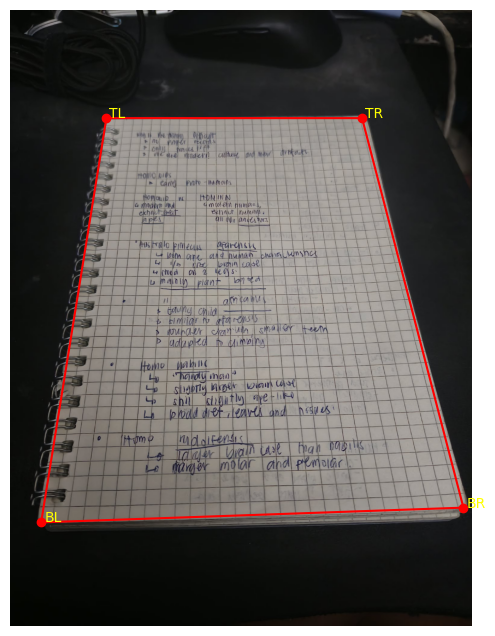

In [3]:
src = np.float32([[320,359], # TL
                  [1170,359],  # TR
                  [1507,1654], # BR
                  [103,1703]])  # BL

#verification that points actually line up:
plt.figure(figsize=(8, 8))
plt.imshow(doc_np)
for i, (x, y) in enumerate(src):
    plt.plot(x, y, 'ro'); plt.text(x + 10, y, "TL TR BR BL".split()[i], color='yellow')
plt.plot(*np.vstack([src, src[0]]).T, 'r-')
plt.axis('off'); plt.show()

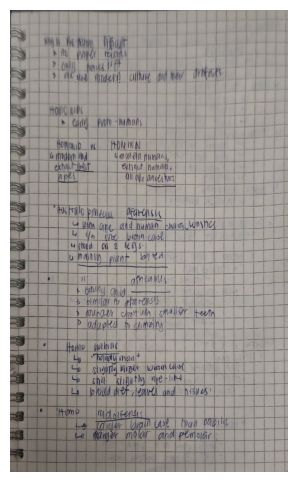

In [6]:
W, H = 600, 1000 #estimated output dims from box
dst4 = np.float32([[0, 0], [W, 0], [W, H], [0, H]])

#perspective on four points
Mp = cv2.getPerspectiveTransform(src, dst4)
persp = cv2.warpPerspective(doc_np, Mp, (W, H))


plt.figure(figsize=(12, 6))
plt.imshow(persp)
plt.axis('off')
plt.show()

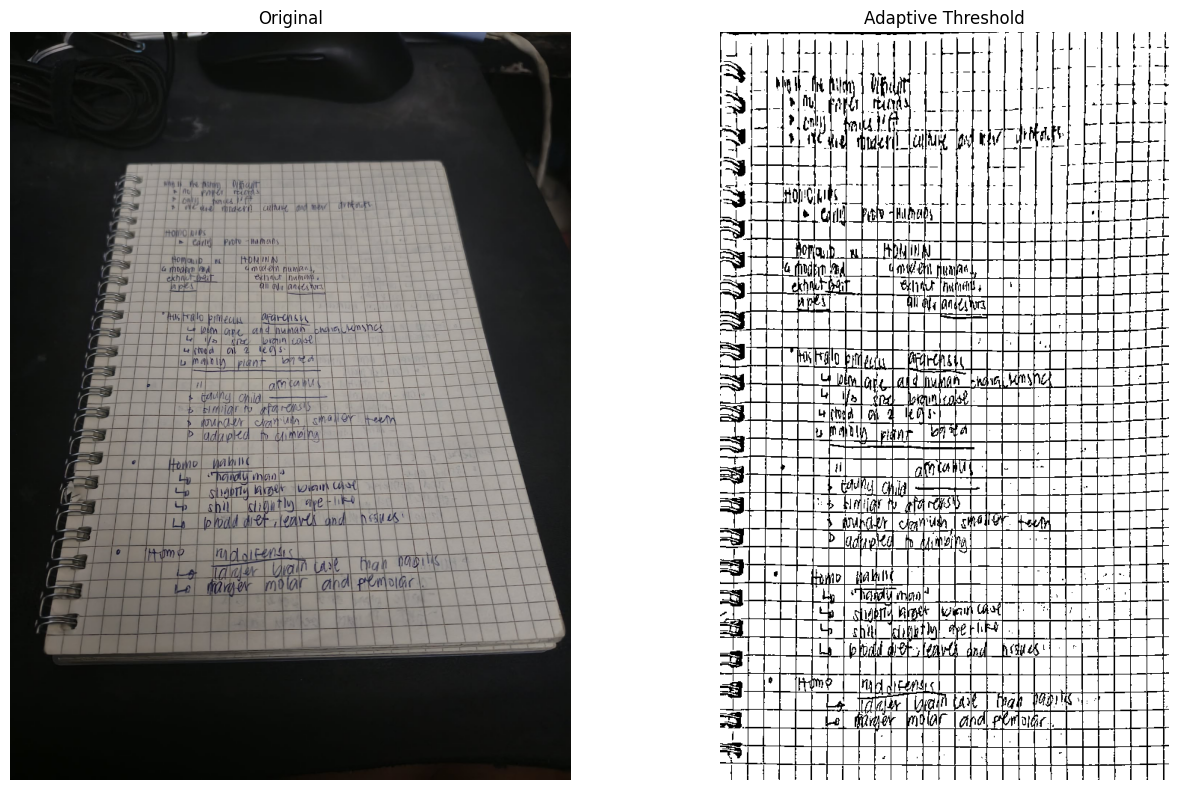

In [7]:
#cleaned and thresholded

gray = cv2.cvtColor(persp, cv2.COLOR_RGB2GRAY)

#applying a blur actually enhances it since it kills sensor noise
blur = cv2.GaussianBlur(gray, (1, 1), 0)

#thresholding technique used is adaptive gaussian, which chooses a different cutoff for regions
adapt = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY, 31, 10)

plt.figure(figsize=(14, 8))

plt.subplot(1, 2, 1)
plt.imshow(image_doc)
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(adapt, cmap='gray', vmin=0, vmax=255)
plt.title("Adaptive Threshold")
plt.axis('off')

plt.tight_layout()
plt.show()

Perspective transformation was appropriate because the notebook was photographed at an angle, which made its parallel edges converge and its far end appear smaller than the near end. Only a perspective transform can undo that convergence, since it maps the four corners of the page to a true rectangle and reproduces the view a camera would have captured directly overhead.

